In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import GEOparse

os.chdir(os.path.expanduser('~/projects/lungcell'))
os.makedirs('figures', exist_ok=True)

print("All imports OK")


All imports OK


In [3]:
df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)

condition = pd.read_csv('data/processed/sample_labels.csv', index_col=0).squeeze()

print(f"Expression matrix shape: {df.shape[0]} genes x {df.shape[1]} samples")
print(f"\nSample counts:")
print(condition.value_counts())
print(f"\nFirst 3 values: {df.iloc[:3, :3]}")


Expression matrix shape: 36742 genes x 169 samples

Sample counts:
condition
cancer    87
normal    77
Name: count, dtype: int64

First 3 values:          accession chrom  start
gene                           
WASH7P   NR_024540     1  14361
FAM138A  NR_026818     1  34610
FAM138F  NR_026820     1  34610


/var/folders/20/0j1g3vmn6k75n7cswz73b47w0000gn/T/ipykernel_65160/1756296211.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)


In [7]:
expression_cols = df.filter(regex=r'^LC_').columns
log_df = np.log2(df[expression_cols] + 1)  # log-transform expression values only

expressed = log_df.median(axis=1) > 0.5
log_df = log_df[expressed]

print(f"Genes before filtering: {df.shape[0]:,}")
print(f"Genes after filtering: {log_df.shape[0]:,}")
print(f"\nValue range after log transform:")
print(f"  Min: {log_df.min().min():.2f}")
print(f"  Max: {log_df.max().max():.2f}")
print(f"  Mean: {log_df.mean().mean():.2f}")

Genes before filtering: 36,742
Genes after filtering: 26,411

Value range after log transform:
  Min: 0.00
  Max: 14.87
  Mean: 3.31


PC1 explains 19.8% of variation
PC2 explains 10.2% of variation


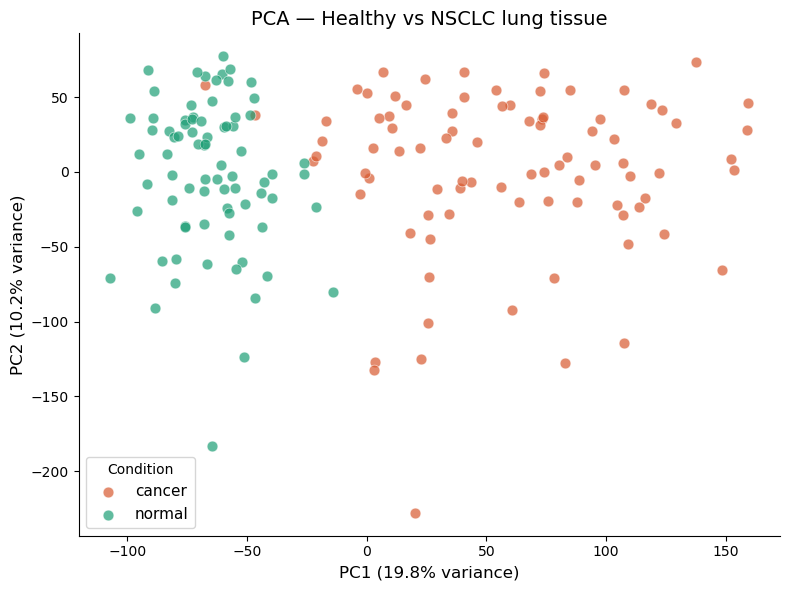

Saved: figures/01_pca.png


In [8]:
X = log_df.T
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {variance_explained[0]:.1f}% of variation")
print(f"PC2 explains {variance_explained[1]:.1f}% of variation")

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Condition': condition.values
})

#Plot
fig, ax = plt.subplots(figsize=(8, 6))

colours = {'cancer': "#D85A30", 'normal': "#1D9E75"}

for group, subset in pca_df.groupby('Condition'):
    ax.scatter(subset['PC1'], subset['PC2'], label=group, color=colours[group], alpha=0.7, s= 60, edgecolor='white', linewidth=0.5)
ax.set_xlabel(f'PC1 ({variance_explained[0]:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_explained[1]:.1f}% variance)', fontsize=12)
ax.set_title('PCA — Healthy vs NSCLC lung tissue', fontsize=14)
ax.legend(title='Condition', fontsize=11)
ax.spines['top'].set_visible(False)     # remove top border
ax.spines['right'].set_visible(False)   # remove right border — cleaner look

plt.tight_layout()
plt.savefig('figures/01_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/01_pca.png")